# Training mô hình Logistic Regression và tối ưu siêu tham số bằng Optuna Bayesian Optimization

## 1. Import thư viện cần thiết


In [1]:
pip install optuna scikit-learn pandas numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [optuna]2m4/5 [optuna]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import optuna
import numpy as np
from sklearn.linear_model import LogisticRegression
import pandas as pd


# 2. Import dữ liệu

In [9]:
df_train = pd.read_csv('../Feature Selection /Leads_Selected_Train.csv')
df_test = pd.read_csv('../Feature Selection /Leads_Selected_Test.csv')


In [14]:
X_train = df_train.drop('Converted', axis=1)
X_train.columns

y_train = df_train['Converted']


In [15]:
print(X_train.shape, y_train.shape)


(6152, 6) (6152,)


In [16]:
X_test = df_test.drop('Converted', axis=1)
y_test = df_test['Converted']
print(X_test.shape, y_test.shape)


(1538, 6) (1538,)


### Định nghĩa hàm objective cho Optuna để tối ưu siêu tham số của Logistic Regression

In [25]:
from sklearn.model_selection import cross_val_score

def objective(trial):
    C        = trial.suggest_float("C", 1e-4, 1e2, log=True)
    max_iter = trial.suggest_int("max_iter", 100, 1000, step=100)
    l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)

    solver_penalty_pairs = [
        ("lbfgs",     "l2"),
        ("liblinear", "l1"),
        ("liblinear", "l2"),
        ("saga",      "l1"),
        ("saga",      "l2"),
        ("saga",      "elasticnet"),
    ]
    pair_idx       = trial.suggest_int("solver_penalty_idx", 0, len(solver_penalty_pairs) - 1)
    solver, penalty = solver_penalty_pairs[pair_idx]

    params = dict(
        C=C,
        solver=solver,
        penalty=penalty,
        max_iter=max_iter,
        random_state=42,
    )
    if penalty == "elasticnet":
        params["l1_ratio"] = l1_ratio

    model  = LogisticRegression(**params)
    scores = cross_val_score(model, X_train, y_train,
                             cv=5, scoring="roc_auc", n_jobs=-1)
    return scores.mean()


In [33]:
optuna.logging.set_verbosity(optuna.logging.WARNING)   # bớt log noise

study = optuna.create_study(
    direction="maximize",                  # tối đa hoá ROC-AUC
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(),
)
study.optimize(objective, n_trials=100, timeout=120)   # 100 trials hoặc 2 phút


In [31]:
print("Best ROC-AUC (CV):", round(study.best_value, 4))
print("Best params (raw) :", study.best_params)

# ── Tái tạo params hợp lệ từ best_params ──────────────────────
solver_penalty_pairs = [
    ("lbfgs",     "l2"),
    ("liblinear", "l1"),
    ("liblinear", "l2"),
    ("saga",      "l1"),
    ("saga",      "l2"),
    ("saga",      "elasticnet"),
]

bp = study.best_params
solver, penalty = solver_penalty_pairs[bp["solver_penalty_idx"]]

best_params = dict(
    C=bp["C"],
    solver=solver,
    penalty=penalty,
    max_iter=bp["max_iter"],
    random_state=42,
)
if penalty == "elasticnet":
    best_params["l1_ratio"] = bp["l1_ratio"]

print("Best params (clean):", best_params)

# ── Huấn luyện lại ────────────────────────────────────────────
best_model = LogisticRegression(**best_params)
best_model.fit(X_train, y_train)

# ── Đánh giá ──────────────────────────────────────────────────
from sklearn.metrics import roc_auc_score, classification_report

y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\nTest ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print(classification_report(y_test, y_pred))


Best ROC-AUC (CV): 0.8285
Best params (raw) : {'C': 0.33687006015020793, 'max_iter': 100, 'l1_ratio': 0.9408900359096538, 'solver_penalty_idx': 2}
Best params (clean): {'C': 0.33687006015020793, 'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 100, 'random_state': 42}

Test ROC-AUC: 0.8465
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       936
           1       0.75      0.64      0.69       602

    accuracy                           0.77      1538
   macro avg       0.77      0.75      0.76      1538
weighted avg       0.77      0.77      0.77      1538



Test ROC-AUC: 0.8465
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       936
           1       0.75      0.64      0.69       602

    accuracy                           0.77      1538
   macro avg       0.77      0.75      0.76      1538
weighted avg       0.77      0.77      0.77      1538



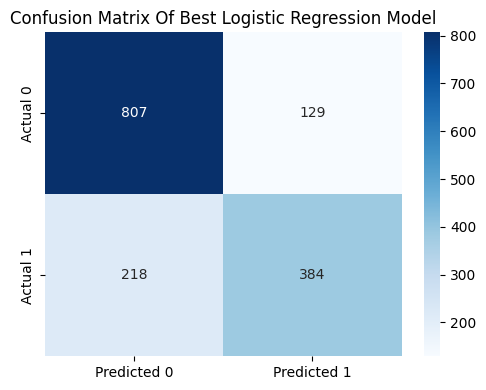

True Negative  (TN): 807
False Positive (FP): 129
False Negative (FN): 218
True Positive  (TP): 384
Precision : 0.7485
Recall    : 0.6379
Specificity: 0.8622


In [34]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print(classification_report(y_test, y_pred))

# ── Confusion Matrix ───────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0",    "Actual 1"],
    ax=ax,
)
ax.set_title("Confusion Matrix Of Best Logistic Regression Model")
plt.tight_layout()
plt.show()

# ── Đọc kết quả ───────────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"True Negative  (TN): {tn}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")
print(f"True Positive  (TP): {tp}")
print(f"Precision : {tp / (tp + fp):.4f}")
print(f"Recall    : {tp / (tp + fn):.4f}")
print(f"Specificity: {tn / (tn + fp):.4f}")


In [35]:
import joblib
joblib.dump(best_model, "best_optuna_logistic_regression_model.pkl")


['best_optuna_logistic_regression_model.pkl']